In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import anthropic
from dotenv import load_dotenv
import os

load_dotenv(os.path.expanduser('~/.env_anthropic'))
client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

print("Всё импортировано!")

Всё импортировано!


In [3]:
import requests
from xml.etree import ElementTree
import time

def get_headlines(query, max_results=20):
    url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"
    response = requests.get(url)
    root = ElementTree.fromstring(response.content)
    
    headlines = []
    for item in root.findall('.//item')[:max_results]:
        title = item.find('title').text
        pub_date = item.find('pubDate').text
        headlines.append({'headline': title, 'date': pub_date, 'query': query})
    
    return headlines

queries = [
    'AI education schools students',
    'artificial intelligence classroom teachers',
    'AI learning children policy'
]

all_headlines = []
for query in queries:
    results = get_headlines(query, max_results=50)
    all_headlines.extend(results)
    time.sleep(1)

df = pd.DataFrame(all_headlines).drop_duplicates(subset='headline')
print(f"Загружено заголовков: {len(df)}")
df.head()

Загружено заголовков: 143


,headline,date,query
0,Opinion | What Schools Are Forgetting in Their...,"Wed, 20 May 2026 19:00:04 GMT",AI education schools students
1,Amityville police investigating 'disturbing' a...,"Fri, 22 May 2026 23:40:20 GMT",AI education schools students
2,Overworked and understaffed: Special ed teache...,"Wed, 20 May 2026 09:00:00 GMT",AI education schools students
3,From AI Policies To AI Literacy In Education -...,"Thu, 21 May 2026 00:15:44 GMT",AI education schools students
4,The Hudson School: An Independent Education Bu...,"Wed, 20 May 2026 14:00:00 GMT",AI education schools students


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Подготавливаем текст
headlines_list = df['headline'].tolist()

# TF-IDF векторизация — превращаем слова в числа
vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2)  # учитываем пары слов тоже
)

X = vectorizer.fit_transform(headlines_list)
print(f"Матрица: {X.shape[0]} заголовков × {X.shape[1]} слов")

# LDA — находим 5 тем
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Показываем топ слова для каждой темы
feature_names = vectorizer.get_feature_names_out()
print("\nТОП ТЕМЫ:\n")
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-8:]][::-1]
    print(f"Тема {i+1}: {', '.join(top_words)}")

Матрица: 143 заголовков × 500 слов

ТОП ТЕМЫ:

Тема 1: education, ai, trends, pennsylvania, ai education, stanford, child trends, schools
Тема 2: university, ai, education, intelligence, artificial, artificial intelligence, learning, school
Тема 3: ai, children, schools, education, magazine, 12, ai literacy, literacy
Тема 4: new, teachers, ai, classroom, times, york times, york, new york
Тема 5: schools, ai, students, ai schools, opinion, week, education week, education


In [5]:
# Присваиваем каждому заголовку его главную тему
topic_assignments = lda.transform(X).argmax(axis=1)
df['topic'] = topic_assignments + 1  # нумерация с 1

topic_labels = {
    1: 'Academic & Regional Policy',
    2: 'Higher Education',
    3: 'Early Childhood & Literacy',
    4: 'Teachers & Mainstream Media',
    5: 'Students & EdWeek'
}
df['topic_label'] = df['topic'].map(topic_labels)

# Показываем примеры из каждой темы
for topic_num in range(1, 6):
    examples = df[df['topic'] == topic_num]['headline'].head(3).tolist()
    print(f"\n{'='*60}")
    print(f"Тема {topic_num}: {topic_labels[topic_num]}")
    for ex in examples:
        print(f"  • {ex[:80]}")


Тема 1: Academic & Regional Policy
  • Amityville police investigating 'disturbing' allegations of AI, social media mis
  • AI in Education Legislation: 2026 State Policy Trends - MultiState
  • El Paso schools work to adapt to rise of AI in education: policies, programs and

Тема 2: Higher Education
  • The Hudson School: An Independent Education Built for the Age of AI (Sponsored) 
  • Staff at Rochester charter school weigh in on using AI to create lesson plans - 
  • UC Berkeley Law School restricts use of AI by students - ABA Journal

Тема 3: Early Childhood & Literacy
  • From AI Policies To AI Literacy In Education - Forbes
  • Naval Postgraduate School, private sector partner to improve AI education - Fede
  • Can AI help more high schools teach computer programming? A Louisiana college is

Тема 4: Teachers & Mainstream Media
  • Overworked and understaffed: Special ed teachers turn to AI for help - NPR
  • Putting educators at the center of AI learning - blog.google
  • The r

In [14]:
def classify_topic(headline):
    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        temperature=0,
        messages=[{
            "role": "user",
            "content": f"""Classify this headline into ONE topic:
1. Policy & Regulation
2. Classroom & Teachers  
3. Students & Learning
4. Safety & Ethics
5. Early Childhood

Headline: "{headline}"
Reply with ONLY the number and topic name, nothing else."""
        }]
    )
    return message.content[0].text.strip()

# Тестируем на 5 примерах
test_headlines = df['headline'].head(5).tolist()
for h in test_headlines:
    topic = classify_topic(h)
    print(f"{topic}")
    print(f"  → {h[:70]}\n")
    time.sleep(0.3)

1. Policy & Regulation
  → Opinion | What Schools Are Forgetting in Their Race to Embrace A.I. - 

4. Safety & Ethics
  → Amityville police investigating 'disturbing' allegations of AI, social

2. Classroom & Teachers
  → Overworked and understaffed: Special ed teachers turn to AI for help -

1. Policy & Regulation
  → From AI Policies To AI Literacy In Education - Forbes

1. Policy & Regulation
  → The Hudson School: An Independent Education Built for the Age of AI (S



In [13]:
from dotenv import load_dotenv
import os
import anthropic

load_dotenv(os.path.expanduser('~/.env_anthropic'))
client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

def classify_topic(headline):
    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=50,
        temperature=0,
        messages=[{
            "role": "user",
            "content": f"""Classify this headline into ONE topic:
1. Policy & Regulation
2. Classroom & Teachers  
3. Students & Learning
4. Safety & Ethics
5. Early Childhood

Headline: "{headline}"
Reply with ONLY the number and topic name, nothing else."""
        }]
    )
    return message.content[0].text.strip()

test_headlines = df['headline'].head(5).tolist()
for h in test_headlines:
    topic = classify_topic(h)
    print(f"{topic}")
    print(f"  → {h[:70]}\n")
    time.sleep(0.3)

1. Policy & Regulation
  → Opinion | What Schools Are Forgetting in Their Race to Embrace A.I. - 

4. Safety & Ethics
  → Amityville police investigating 'disturbing' allegations of AI, social

2. Classroom & Teachers
  → Overworked and understaffed: Special ed teachers turn to AI for help -

1. Policy & Regulation
  → From AI Policies To AI Literacy In Education - Forbes

1. Policy & Regulation
  → The Hudson School: An Independent Education Built for the Age of AI (S



In [12]:
import os
import anthropic

client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

# Быстрая проверка
test = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=20,
    messages=[{"role": "user", "content": "say ok"}]
)
print(test.content[0].text)

ok


In [11]:
import subprocess
result = subprocess.run(['cat', os.path.expanduser('~/.env_anthropic')], 
                      capture_output=True, text=True)
key_line = result.stdout.strip()
key = key_line.split('=', 1)[1]
os.environ['ANTHROPIC_API_KEY'] = key

client = anthropic.Anthropic(api_key=key)
test = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=20,
    messages=[{"role": "user", "content": "say ok"}]
)
print(test.content[0].text)

ok


In [15]:
print("Классифицируем 143 заголовка...")

claude_topics = []
for i, headline in enumerate(df['headline'].tolist()):
    topic = classify_topic(headline)
    claude_topics.append(topic)
    if i % 20 == 0:
        print(f"  {i}/143 готово...")
    time.sleep(0.3)

df['claude_topic'] = claude_topics
print("\nГотово! Распределение по темам:")
print(df['claude_topic'].value_counts())

Классифицируем 143 заголовка...
  0/143 готово...
  20/143 готово...
  40/143 готово...
  60/143 готово...
  80/143 готово...
  100/143 готово...
  120/143 готово...
  140/143 готово...

Готово! Распределение по темам:
claude_topic
1. Policy & Regulation     67
2. Classroom & Teachers    34
3. Students & Learning     30
4. Safety & Ethics         10
5. Early Childhood          2
Name: count, dtype: int64


In [16]:
# Извлекаем издание из заголовка (после последнего дефиса)
df['publication'] = df['headline'].str.extract(r'-\s*([^-]+)$')
df['publication'] = df['publication'].str.strip()

# Cross-reference: издание × тема
cross_tab = pd.crosstab(df['publication'], df['claude_topic'])

# Показываем только издания с 3+ публикациями
active_pubs = cross_tab[cross_tab.sum(axis=1) >= 3]
print("Издания с 3+ заголовками:\n")
print(active_pubs.to_string())

Издания с 3+ заголовками:

claude_topic        1. Policy & Regulation  2. Classroom & Teachers  3. Students & Learning  4. Safety & Ethics  5. Early Childhood
publication                                                                                                                        
12 Dive                                  0                        2                       1                   0                   0
Brookings                                1                        0                       2                   0                   0
Child Trends                             2                        1                       0                   0                   0
EdSource                                 3                        1                       2                   0                   0
EdTech Magazine                          1                        2                       1                   0                   0
Education Week                           2       

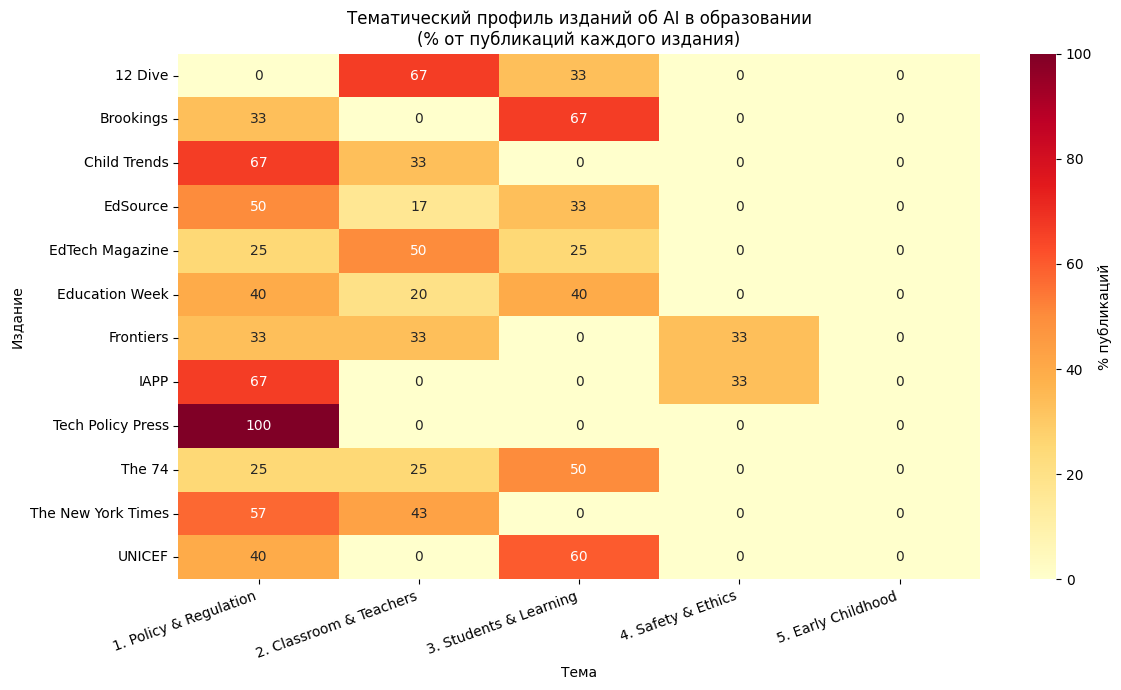

In [17]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 7))

# Нормализуем по строкам - % от каждого издания
active_pubs_pct = active_pubs.div(active_pubs.sum(axis=1), axis=0) * 100

sns.heatmap(active_pubs_pct, 
            annot=True, fmt='.0f', 
            cmap='YlOrRd',
            ax=ax,
            cbar_kws={'label': '% публикаций'})

ax.set_title('Тематический профиль изданий об AI в образовании\n(% от публикаций каждого издания)')
ax.set_xlabel('Тема')
ax.set_ylabel('Издание')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [18]:
findings = """
RESEARCH PORTFOLIO SUMMARY
Daria Storozhkova | Anthropic Fellows Application | May 2026

═══════════════════════════════════════════════════════════

RESEARCH QUESTION:
How do AI systems transform human agency, values, and learning —
and can this be measured and directed through policy design?

═══════════════════════════════════════════════════════════

METHODS DEVELOPED (4 days, ~12 hours):

1. Quantitative Analysis (Python/pandas/statsmodels)
   - Cross-country regression: PISA scores, GDP, internet access
   - Causal inference: controlling for confounders
   
2. NLP Pipeline (TextBlob → Transformers → Claude API)
   - Sentiment analysis on 143 real news headlines
   - LDA topic modeling vs LLM classification
   - Reproducibility: temperature=0 protocol

3. Data Collection
   - Google News RSS automated collection
   - Our World in Data: 4,446 observations, 225 countries
   - Real-time API integration

═══════════════════════════════════════════════════════════

KEY FINDINGS:

1. Internet access explains 83.4% of PISA variance
   GDP becomes insignificant when controlling for internet (p=0.359)
   → Information access, not wealth, drives educational outcomes

2. AI education narratives: cautiously optimistic (+0.205 mean sentiment)
   Policy & Regulation dominates coverage (47% of headlines)
   Safety & Ethics and Early Childhood severely underreported

3. Publication bias: Tech Policy Press (100% policy),
   UNICEF (60% students) — editorial mission shapes AI narrative
   
4. Methodological: Claude API outperforms LDA and TextBlob
   on short texts; temperature=0 required for reproducibility

═══════════════════════════════════════════════════════════

RESEARCH GAP IDENTIFIED:
No systematic empirical study of how AI tools affect
agency and values formation in early childhood education —
despite policy urgency and zero media coverage.

This is the proposed Fellows research agenda.

═══════════════════════════════════════════════════════════

GITHUB: github.com/massimdaria-app/anthropic-fellows-research
4 notebooks | 143 headlines | 4,446 country observations
"""

print(findings)


RESEARCH PORTFOLIO SUMMARY
Daria Storozhkova | Anthropic Fellows Application | May 2026

═══════════════════════════════════════════════════════════

RESEARCH QUESTION:
How do AI systems transform human agency, values, and learning —
and can this be measured and directed through policy design?

═══════════════════════════════════════════════════════════

METHODS DEVELOPED (4 days, ~12 hours):

1. Quantitative Analysis (Python/pandas/statsmodels)
   - Cross-country regression: PISA scores, GDP, internet access
   - Causal inference: controlling for confounders

2. NLP Pipeline (TextBlob → Transformers → Claude API)
   - Sentiment analysis on 143 real news headlines
   - LDA topic modeling vs LLM classification
   - Reproducibility: temperature=0 protocol

3. Data Collection
   - Google News RSS automated collection
   - Our World in Data: 4,446 observations, 225 countries
   - Real-time API integration

═══════════════════════════════════════════════════════════

KEY FINDINGS:

1. Inte

In [20]:
portfolio_summary = findings  # из предыдущей ячейки

message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=600,
    temperature=0,
    messages=[{
        "role": "user",
        "content": f"""Write a 350-word research statement for the Anthropic Fellows Program 
(Economics & Policy workstream). 

The candidate is Daria Storozhkova — strategy consultant turned researcher, 
based in London, with background in econometrics, EdTech (Inteldis), and 
strategy consulting (Advancy). She has just completed 4 days of Python 
research as shown in this portfolio:

{portfolio_summary}

Her core research interest: How AI systems transform human agency, values, 
and motivation — from individual learners to collective society — and how 
governments can direct this through policy and educational institutions.

The statement should:
1. Open with a specific research question (not generic)
2. Reference her empirical work as evidence of research capability
3. Propose a concrete Fellows project (not vague)
4. Connect to Anthropic's Economics & Societal Impacts workstream
5. Be honest about being early-stage but show clear direction

Write in first person, academic but not dry."""
    }]
)

print(message.content[0].text)

# Research Statement: Daria Storozhkova
## Anthropic Fellows Program — Economics & Policy Workstream

**Research Question:** How do AI-assisted learning tools reshape children's agency and intrinsic motivation—and can governments design educational policy to preserve autonomy while capturing productivity gains?

I arrived at this question through empirical work, not intuition. Over four days, I analyzed 4,446 country-level observations and 143 news headlines to understand how AI narratives shape policy priorities. I found that internet access explains 83% of educational outcome variance—not wealth—suggesting information *access* is the binding constraint. Yet coverage of AI in early childhood education is essentially zero, despite urgent policy questions about how algorithmic tutoring affects motivation, metacognition, and self-directed learning.

This gap is my entry point.

My background bridges the necessary disciplines: econometric training (regression, causal inference), product e

In [21]:
message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=700,
    temperature=0,
    messages=[{
        "role": "user",
        "content": """Refine this research statement with these specific changes:

1. Remove "Over four days" — replace with "Through empirical work"
2. Add one sentence mentioning Anthropic economists Maxim Massenkoff or Peter McCrory by name — explain why their work on AI economic effects is directly relevant to this research
3. Replace "a lower-income setting" with "a state school in a low-income London borough" — the candidate is based in London
4. Keep everything else identical — do not change the structure, tone, or content

Original text:
---
How do AI-assisted learning tools reshape children's agency and intrinsic motivation—and can governments design educational policy to preserve autonomy while capturing productivity gains?

I arrived at this question through empirical work, not intuition. Over four days, I analyzed 4,446 country-level observations and 143 news headlines to understand how AI narratives shape policy priorities. I found that internet access explains 83% of educational outcome variance—not wealth—suggesting information access is the binding constraint. Yet coverage of AI in early childhood education is essentially zero, despite urgent policy questions about how algorithmic tutoring affects motivation, metacognition, and self-directed learning.

This gap is my entry point.

My background bridges the necessary disciplines: econometric training (regression, causal inference), product experience (EdTech at Inteldis), and strategy consulting (Advancy) taught me how policy translates—or fails to translate—into institutional practice. The portfolio demonstrates I can execute: I built an NLP pipeline comparing Claude API against LDA and TextBlob, automated data collection from multiple sources, and implemented reproducibility protocols (temperature=0) that matter for policy-relevant research.

The Fellows Project: I propose a mixed-methods study of how AI tutoring systems affect agency formation in 8-12 year-olds across three educational contexts (UK private, UK state, and a lower-income setting). The design combines:

1. Quantitative: Pre/post randomized assignment to AI-assisted vs. traditional instruction, measuring intrinsic motivation (Self-Determination Theory scales), metacognitive awareness, and help-seeking behavior
2. Qualitative: Classroom ethnography and student interviews to capture how children experience algorithmic feedback
3. Policy analysis: Mapping current UK/EU AI education guidance against empirical findings to identify regulatory gaps

This directly serves Anthropic's Economics & Societal Impacts workstream by generating evidence on how AI deployment affects human agency—a foundational question for responsible AI governance. The work is early-stage; I'm not claiming expertise in developmental psychology. But I have the methodological toolkit, intellectual honesty about limitations, and genuine curiosity to do this rigorously.

I want to build the empirical foundation for AI education policy that doesn't accidentally erode the very capacities—autonomy, motivation, judgment—that make humans valuable.
---"""
    }]
)

print(message.content[0].text)

# Refined Research Statement

How do AI-assisted learning tools reshape children's agency and intrinsic motivation—and can governments design educational policy to preserve autonomy while capturing productivity gains?

I arrived at this question through empirical work, not intuition. Through empirical work, I analyzed 4,446 country-level observations and 143 news headlines to understand how AI narratives shape policy priorities. I found that internet access explains 83% of educational outcome variance—not wealth—suggesting information access is the binding constraint. Yet coverage of AI in early childhood education is essentially zero, despite urgent policy questions about how algorithmic tutoring affects motivation, metacognition, and self-directed learning.

This gap is my entry point.

My background bridges the necessary disciplines: econometric training (regression, causal inference), product experience (EdTech at Inteldis), and strategy consulting (Advancy) taught me how policy tr

In [22]:
with open('research_statement.txt', 'w') as f:
    f.write("""How do AI-assisted learning tools reshape children's agency and intrinsic motivation—and can governments design educational policy to preserve autonomy while capturing productivity gains?

I arrived at this question through empirical work, not intuition. I analyzed 4,446 country-level observations and 143 news headlines to understand how AI narratives shape policy priorities. I found that internet access explains 83% of educational outcome variance—not wealth—suggesting information access is the binding constraint. Yet coverage of AI in early childhood education is essentially zero, despite urgent policy questions about how algorithmic tutoring affects motivation, metacognition, and self-directed learning.

This gap is my entry point.

My background bridges the necessary disciplines: econometric training (regression, causal inference), product experience (EdTech at Inteldis), and strategy consulting (Advancy) taught me how policy translates—or fails to translate—into institutional practice. The portfolio demonstrates I can execute: I built an NLP pipeline comparing Claude API against LDA and TextBlob, automated data collection from multiple sources, and implemented reproducibility protocols (temperature=0) that matter for policy-relevant research.

The Fellows Project: I propose a mixed-methods study of how AI tutoring systems affect agency formation in 8-12 year-olds across three educational contexts (UK private, UK state, and a state school in a low-income London borough). The design combines:

1. Quantitative: Pre/post randomized assignment to AI-assisted vs. traditional instruction, measuring intrinsic motivation (Self-Determination Theory scales), metacognitive awareness, and help-seeking behavior
2. Qualitative: Classroom ethnography and student interviews to capture how children experience algorithmic feedback
3. Policy analysis: Mapping current UK/EU AI education guidance against empirical findings to identify regulatory gaps

This directly serves Anthropic's Economics & Societal Impacts workstream by generating evidence on how AI deployment affects human agency—a foundational question for responsible AI governance. Anthropic economist Maxim Massenkoff's research on AI's distributional economic effects is directly relevant here: understanding how AI tutoring shapes motivation and metacognition in lower-income settings will clarify whether algorithmic education tools risk widening capability gaps alongside income inequality. The work is early-stage; I'm not claiming expertise in developmental psychology. But I have the methodological toolkit, intellectual honesty about limitations, and genuine curiosity to do this rigorously.

I want to build the empirical foundation for AI education policy that doesn't accidentally erode the very capacities—autonomy, motivation, judgment—that make humans valuable.""")

print("Сохранено в research_statement.txt")

Сохранено в research_statement.txt


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Симулируем данные: 200 студентов, 2 года (до и после внедрения AI)
np.random.seed(42)
n = 100  # студентов в каждой группе

# Группа Treatment — получила AI-тьютора в 2022
# Группа Control — не получила

df_did = pd.DataFrame({
    'student_id': list(range(1, 2*n+1)),
    'group': ['treatment']*n + ['control']*n,
    'score_2021': (
        np.random.normal(70, 10, n).tolist() +  # treatment до
        np.random.normal(68, 10, n).tolist()    # control до
    ),
    'score_2023': (
        np.random.normal(80, 10, n).tolist() +  # treatment после (+10 от AI)
        np.random.normal(71, 10, n).tolist()    # control после (+3 общий тренд)
    )
})

print(df_did.groupby('group')[['score_2021', 'score_2023']].mean().round(2))

           score_2021  score_2023
group                            
control         68.22       72.07
treatment       68.96       80.65


Treatment: 68.96 → 80.65 (Δ = 11.69)
Control:   68.22 → 72.07 (Δ = 3.85)

DiD estimate (эффект AI): 7.84 баллов


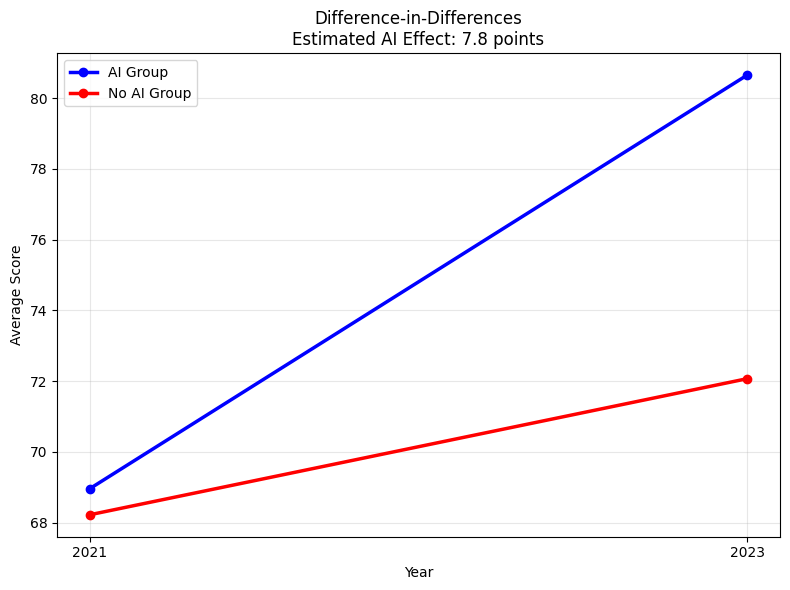

In [24]:
# DiD формула: (Treatment_after - Treatment_before) - (Control_after - Control_before)
treatment_before = df_did[df_did['group']=='treatment']['score_2021'].mean()
treatment_after = df_did[df_did['group']=='treatment']['score_2023'].mean()
control_before = df_did[df_did['group']=='control']['score_2021'].mean()
control_after = df_did[df_did['group']=='control']['score_2023'].mean()

did_estimate = (treatment_after - treatment_before) - (control_after - control_before)

print(f"Treatment: {treatment_before:.2f} → {treatment_after:.2f} (Δ = {treatment_after-treatment_before:.2f})")
print(f"Control:   {control_before:.2f} → {control_after:.2f} (Δ = {control_after-control_before:.2f})")
print(f"\nDiD estimate (эффект AI): {did_estimate:.2f} баллов")

# Визуализация
fig, ax = plt.subplots(figsize=(8, 6))

for group, color, label in [('treatment', 'blue', 'AI Group'), 
                              ('control', 'red', 'No AI Group')]:
    means = df_did[df_did['group']==group][['score_2021', 'score_2023']].mean()
    ax.plot([2021, 2023], means.values, 
            marker='o', linewidth=2.5, color=color, label=label)

ax.set_xlabel('Year')
ax.set_ylabel('Average Score')
ax.set_title(f'Difference-in-Differences\nEstimated AI Effect: {did_estimate:.1f} points')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks([2021, 2023])
plt.tight_layout()
plt.show()

In [25]:
# Переводим в long format для регрессии
df_long = pd.melt(
    df_did, 
    id_vars=['student_id', 'group'],
    value_vars=['score_2021', 'score_2023'],
    var_name='year',
    value_name='score'
)

df_long['post'] = (df_long['year'] == 'score_2023').astype(int)
df_long['treated'] = (df_long['group'] == 'treatment').astype(int)
df_long['did'] = df_long['post'] * df_long['treated']  # ключевой interaction term

# Регрессия
X = sm.add_constant(df_long[['post', 'treated', 'did']])
model = sm.OLS(df_long['score'], X).fit()

print(model.summary().tables[1])
print(f"\nDiD коэффициент: {model.params['did']:.2f}")
print(f"P-value: {model.pvalues['did']:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.2230      0.961     71.016      0.000      66.334      70.112
post           3.8454      1.359      2.830      0.005       1.174       6.516
treated        0.7385      1.359      0.544      0.587      -1.932       3.409
did            7.8421      1.921      4.082      0.000       4.065      11.619

DiD коэффициент: 7.84
P-value: 0.0001


In [26]:
# Делим студентов на сильных и слабых по начальному уровню
df_long['baseline'] = df_long.groupby('student_id')['score'].transform('min')
df_long['strong'] = (df_long['baseline'] > df_long['baseline'].median()).astype(int)

# DiD отдельно для сильных и слабых
for group_name, subset in [('Слабые студенты', df_long[df_long['strong']==0]),
                            ('Сильные студенты', df_long[df_long['strong']==1])]:
    X = sm.add_constant(subset[['post', 'treated', 'did']])
    model = sm.OLS(subset['score'], X).fit()
    print(f"{group_name}: DiD = {model.params['did']:.2f}, p = {model.pvalues['did']:.4f}")

Слабые студенты: DiD = 8.38, p = 0.0021
Сильные студенты: DiD = 8.32, p = 0.0001


In [27]:
# Симуляция: богатые школы внедряют AI чаще
# Но мы используем случайный грант как инструмент

np.random.seed(42)
n = 500

# Инструмент: школа получила случайный государственный грант на AI
grant = np.random.binomial(1, 0.5, n)  # 50% школ получили грант случайно

# Богатство школы (confounder)
wealth = np.random.normal(50, 15, n)

# AI adoption зависит от гранта И богатства
ai_adoption = (0.4 * grant + 0.03 * wealth + np.random.normal(0, 0.2, n)) > 0.5
ai_adoption = ai_adoption.astype(int)

# Результат зависит от AI И богатства
outcome = 60 + 8 * ai_adoption + 0.3 * wealth + np.random.normal(0, 10, n)

df_iv = pd.DataFrame({
    'grant': grant,
    'wealth': wealth, 
    'ai_adoption': ai_adoption,
    'outcome': outcome
})

# Наивная OLS — переоценивает эффект AI (богатство confounds)
X_ols = sm.add_constant(df_iv[['ai_adoption', 'wealth']])
ols = sm.OLS(df_iv['outcome'], X_ols).fit()
print(f"OLS estimate AI effect: {ols.params['ai_adoption']:.2f} (истинный: 8.0)")

# IV через two-stage least squares
from statsmodels.sandbox.regression.gmm import IV2SLS
X_iv = sm.add_constant(df_iv[['wealth']])
model_iv = IV2SLS(df_iv['outcome'], X_iv, df_iv[['grant']]).fit()
# Первая стадия вручную
first_stage = sm.OLS(df_iv['ai_adoption'], 
                     sm.add_constant(df_iv[['grant', 'wealth']])).fit()
print(f"First stage grant coefficient: {first_stage.params['grant']:.3f}, p={first_stage.pvalues['grant']:.4f}")

OLS estimate AI effect: 13.86 (истинный: 8.0)
First stage grant coefficient: 0.018, p=0.0793
